### Cell 1 — Upload CSV to Colab

- **Mục tiêu:** Đưa file `BTC_2019_2023_1d.csv` vào môi trường Colab và cố định đường dẫn dùng cho các cell sau.
- **Thao tác chính:** `files.upload()` mở hộp thoại chọn file → đặt `CSV_FILENAME` → tạo `CSV_PATH=/content/BTC_2019_2023_1d.csv`.
- **Kết quả:** Upload thành công, file sẵn sàng đọc tại `/content/BTC_2019_2023_1d.csv`.
- **Lưu ý:** Reset runtime sẽ mất file → cần upload lại.


In [ ]:

from google.colab import files
uploaded = files.upload()  # chọn file BTC_2019_2023_1d.csv

CSV_FILENAME = "BTC_2019_2023_1d.csv"

CSV_PATH = f"/content/{CSV_FILENAME}"
print("Đã tải:", CSV_PATH)


Saving BTC_2019_2023_1d.csv to BTC_2019_2023_1d.csv
Đã tải: /content/BTC_2019_2023_1d.csv


### Cell 2 — Khám cấu trúc CSV (đọc thô, chưa parse)

- **Mục tiêu:** Xem nhanh **tên cột** và **dạng dữ liệu thô** trước khi chuẩn hoá.
- **Thao tác:** `pd.read_csv(..., nrows=200)` đọc mẫu 200 dòng để kiểm tra; đảm bảo `CSV_PATH` tồn tại.
- **Kết quả:** `[Cols] ['index', 'datetime', 'open', 'high', 'low', 'close', 'volume']`
- **Ý nghĩa:** Xác nhận có đủ OHLCV và cột thời gian `datetime` → sẵn sàng bước parse datetime & chuẩn hoá tên cột.

In [ ]:
# Đọc thô không parse để xem cấu trúc
import pandas as pd, os

CSV_PATH = "/content/BTC_2019_2023_1d.csv"
assert os.path.exists(CSV_PATH), f"Không thấy file: {CSV_PATH}"

df_raw = pd.read_csv(CSV_PATH, nrows=200)  # đọc thử 200 dòng
print("[Cols]", list(df_raw.columns))
df_raw.head()


[Cols] ['index', 'datetime', 'open', 'high', 'low', 'close', 'volume']


,index,datetime,open,high,low,close,volume
0,0,08-09-2019,10000.00,10412.65,10000.00,10391.63,3096.291
1,1,09-09-2019,10316.62,10475.54,10077.22,10307.00,14824.373
2,2,10-09-2019,10307.00,10382.97,9940.87,10102.02,9068.955
3,3,11-09-2019,10094.27,10293.11,9884.31,10159.55,10897.922
4,4,12-09-2019,10163.06,10450.13,10042.12,10415.13,15609.634


### Cell 3 — Chuẩn hoá cột & parse thời gian (UTC)

- **Mục tiêu:** Chuẩn hoá dữ liệu về định dạng phân tích: parse `datetime` (dd-mm-YYYY) → `timestamp` UTC, ép kiểu số, sắp xếp, loại NaT/duplicate.
- **Thao tác chính:**
  - `pd.read_csv(usecols=...)` chỉ lấy cột cần thiết.
  - `pd.to_datetime(..., format="%d-%m-%Y", utc=True)` → chuẩn hóa timezone về **UTC**.
  - `pd.to_numeric(..., errors="coerce")` an toàn cho `open/high/low/close/volume`.
  - `sort_values("timestamp")`, `dropna(subset=["timestamp"])`, `drop_duplicates("timestamp")`.
- **Kết quả:** Kiểu dữ liệu đúng (`float64` cho OHLCV, `datetime64[ns, UTC]` cho thời gian), dữ liệu sạch và có thứ tự thời gian.


In [ ]:
# CELL 2 — Chuẩn hoá cột & parse datetime (dd-mm-YYYY) → UTC
import pandas as pd
import numpy as np

CSV_PATH = "/content/BTC_2019_2023_1d.csv"

usecols = ["datetime","open","high","low","close","volume"]
df = pd.read_csv(CSV_PATH, usecols=usecols)

# parse datetime: dd-mm-YYYY, gắn timezone UTC
df["timestamp"] = pd.to_datetime(
    df["datetime"],
    format="%d-%m-%Y",   # ví dụ 08-09-2019
    errors="coerce",
    utc=True
)
df = df.drop(columns=["datetime"])

# ép các cột số về numeric an toàn
for c in ["open","high","low","close","volume"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# sort theo thời gian, bỏ dòng timestamp lỗi/NaT và duplicate
df = df.sort_values("timestamp").dropna(subset=["timestamp"]).drop_duplicates("timestamp")

print(df.dtypes)
print(df.head(3))
print(df.tail(3))


open                     float64
high                     float64
low                      float64
close                    float64
volume                   float64
timestamp    datetime64[ns, UTC]
dtype: object
       open      high       low     close     volume                 timestamp
0  10000.00  10412.65  10000.00  10391.63   3096.291 2019-09-08 00:00:00+00:00
1  10316.62  10475.54  10077.22  10307.00  14824.373 2019-09-09 00:00:00+00:00
2  10307.00  10382.97   9940.87  10102.02   9068.955 2019-09-10 00:00:00+00:00
         open     high      low    close      volume                 timestamp
1574  42095.1  42654.6  41550.0  42174.2  183890.670 2023-12-30 00:00:00+00:00
1575  42174.3  42951.0  42001.0  42314.0  173508.289 2023-12-31 00:00:00+00:00
1576  42314.0  44266.0  42207.9  44230.2  206424.144 2024-01-01 00:00:00+00:00


### Cell 3 — Kiểm tra độ sạch & tính liên tục dữ liệu (daily)

- **Mục tiêu:** Đảm bảo dữ liệu không lỗi trước khi tính chỉ báo: không NA, không trùng `timestamp`, và **đủ mọi ngày** trong khoảng thời gian.
- **Thao tác:**
  - Đếm NA từng cột (`df.isna().sum()`).
  - Kiểm tra trùng `timestamp` (`duplicated().sum()`).
  - So khớp `date` (UTC, chuẩn hoá theo ngày) với `date_range` đầy đủ để phát hiện **ngày bị thiếu**.
- **Kết quả:** Không có NA, không duplicate, **không thiếu ngày** (1577/1577). Dữ liệu đạt chuẩn để tính chỉ báo rolling/statistics.


In [ ]:
# CELL 3 — Kiểm tra NA, duplicate và ngày bị thiếu (daily)
import pandas as pd
import numpy as np

# 1) NA theo cột
print("[NA counts]")
print(df.isna().sum())

# 2) Duplicate theo timestamp (đáng lẽ = 0)
dups = df["timestamp"].duplicated().sum()
print(f"\n[Duplicates theo timestamp]: {dups}")

# 3) Kiểm tra tính liên tục theo ngày
#    Chuẩn hoá timestamp về ngày (UTC) rồi so sánh với full date range
d = df.copy()
d["date"] = d["timestamp"].dt.tz_convert("UTC").dt.normalize()

full_range = pd.date_range(d["date"].min(), d["date"].max(), freq="D", tz="UTC")
have = pd.DatetimeIndex(d["date"].unique())
missing = full_range.difference(have)

print(f"\n[Khoảng thời gian]: {d['date'].min().date()} → {d['date'].max().date()}")
print(f"[Tổng số ngày kỳ vọng]: {len(full_range)} | [Số ngày thực có]: {len(have)}")
print(f"[Số ngày thiếu]: {len(missing)}")

if len(missing) > 0:
    print("[Một vài ngày thiếu (tối đa 10)]:")
    print(list(missing[:10]))

# 4) Xem 3 dòng đầu/cuối sau chuẩn hoá date
print("\n[Head]")
print(d.head(3)[["date","open","high","low","close","volume"]])
print("\n[Tail]")
print(d.tail(3)[["date","open","high","low","close","volume"]])


[NA counts]
open         0
high         0
low          0
close        0
volume       0
timestamp    0
dtype: int64

[Duplicates theo timestamp]: 0

[Khoảng thời gian]: 2019-09-08 → 2024-01-01
[Tổng số ngày kỳ vọng]: 1577 | [Số ngày thực có]: 1577
[Số ngày thiếu]: 0

[Head]
                       date      open      high       low     close     volume
0 2019-09-08 00:00:00+00:00  10000.00  10412.65  10000.00  10391.63   3096.291
1 2019-09-09 00:00:00+00:00  10316.62  10475.54  10077.22  10307.00  14824.373
2 2019-09-10 00:00:00+00:00  10307.00  10382.97   9940.87  10102.02   9068.955

[Tail]
                          date     open     high      low    close      volume
1574 2023-12-30 00:00:00+00:00  42095.1  42654.6  41550.0  42174.2  183890.670
1575 2023-12-31 00:00:00+00:00  42174.3  42951.0  42001.0  42314.0  173508.289
1576 2024-01-01 00:00:00+00:00  42314.0  44266.0  42207.9  44230.2  206424.144


### Cell 4 — SMA/EMA (chỉ báo xu hướng)

- **Mục tiêu:** Tính **SMA** (20/50/200) và **EMA** (12/26/100) để nhận diện xu hướng ngắn/trung/dài hạn.
- **Cách tính:**
  - `rolling(window).mean()` → **SMA** (có NaN khởi động: 19/49/199 dòng).
  - `ewm(span, adjust=False).mean()` → **EMA** (không NaN đầu vì EWMA khởi tạo lũy tiến).
- **Lưu ý:** Tính hoàn toàn **không lookahead** (chỉ dùng dữ liệu đến thời điểm hiện tại); tham số cửa sổ có thể điều chỉnh.
- **Kết quả:** NaN đầu kỳ là **bình thường** với SMA; EMA hiển thị đầy đủ ngay từ đầu.


In [ ]:

import pandas as pd, os

# Nếu df đã có từ bước trước thì dùng luôn; nếu chưa có, đọc lại CSV nhanh
if "df" not in globals():
    CSV_PATH = "/content/BTC_2019_2023_1d.csv"
    assert os.path.exists(CSV_PATH), f"Không thấy file: {CSV_PATH}"
    df = pd.read_csv(CSV_PATH, usecols=["datetime","open","high","low","close","volume"])
    df["timestamp"] = pd.to_datetime(df["datetime"], format="%d-%m-%Y", utc=True, errors="coerce")
    df = df.drop(columns=["datetime"]).sort_values("timestamp").dropna(subset=["timestamp"])

# Tham số cửa sổ (bạn có thể đổi)
SMA_SHORT, SMA_MID, SMA_LONG = 20, 50, 200
EMA_SHORT, EMA_MID, EMA_LONG = 12, 26, 100

# SMA
df[f"sma{SMA_SHORT}"] = df["close"].rolling(SMA_SHORT).mean()
df[f"sma{SMA_MID}"]   = df["close"].rolling(SMA_MID).mean()
df[f"sma{SMA_LONG}"]  = df["close"].rolling(SMA_LONG).mean()

# EMA
df[f"ema{EMA_SHORT}"] = df["close"].ewm(span=EMA_SHORT, adjust=False).mean()
df[f"ema{EMA_MID}"]   = df["close"].ewm(span=EMA_MID,   adjust=False).mean()
df[f"ema{EMA_LONG}"]  = df["close"].ewm(span=EMA_LONG,  adjust=False).mean()

print("[NA đầu kỳ do cửa sổ là bình thường]")
print(df[[f"sma{SMA_SHORT}",f"sma{SMA_MID}",f"sma{SMA_LONG}",f"ema{EMA_SHORT}",f"ema{EMA_MID}",f"ema{EMA_LONG}"]].isna().sum())
df.tail(5)


[NA đầu kỳ do cửa sổ là bình thường]
sma20      19
sma50      49
sma200    199
ema12       0
ema26       0
ema100      0
dtype: int64


,open,high,low,close,volume,timestamp,ret_simple,ret_log,vol20_raw,vol20_ann,rsi14,rsi14_strict,sma20,sma50,sma200,ema12,ema26,ema100
1572,43453.8,43850.0,42320.5,42600.1,257515.182,2023-12-28 00:00:00+00:00,-0.019646,-0.019842,0.022841,0.362594,52.761591,52.761591,42870.095,40184.660,31681.2430,42991.323211,42152.154257,36751.889261
1573,42600.1,43171.9,41283.2,42095.1,337421.865,2023-12-29 00:00:00+00:00,-0.011854,-0.011925,0.022866,0.362982,50.106028,50.106028,42788.135,40292.172,31762.2445,42853.442717,42147.928016,36857.695414
1574,42095.1,42654.6,41550.0,42174.2,183890.670,2023-12-30 00:00:00+00:00,0.001879,0.001877,0.022867,0.363002,50.526063,50.526063,42706.345,40389.048,31843.5255,42748.943838,42149.874088,36962.972732
1575,42174.3,42951.0,42001.0,42314.0,173508.289,2023-12-31 00:00:00+00:00,0.003315,0.003309,0.018386,0.291871,51.306297,51.306297,42758.495,40492.086,31929.5160,42682.029401,42162.031563,37068.933668
1576,42314.0,44266.0,42207.9,44230.2,206424.144,2024-01-01 00:00:00+00:00,0.045285,0.044290,0.020749,0.329387,60.501263,60.501263,42894.255,40634.980,32022.7365,42920.209493,42315.229225,37210.740923


### Cell 5 — Trực quan hoá xu hướng bằng SMA/EMA + nhận xét ngắn

- **Mục tiêu:** So sánh giá BTC với các **SMA(20/50/200)** và **EMA(12/26/100)** trong ~700 ngày gần nhất để nhìn nhanh xu hướng **ngắn / trung / dài hạn**.
- **Diễn giải biểu đồ:**
  - **Giá vs. đường trung bình:** Giá nằm **trên** MA/EMA → xu hướng tăng; **dưới** → giảm.
  - **Độ dốc đường trung bình:** dốc **lên** củng cố tăng; dốc **xuống** củng cố giảm.
  - **Cắt chéo (crossovers):** MA/EMA ngắn **cắt lên** đường dài → tín hiệu đảo chiều tăng (“golden cross”), cắt **xuống** → giảm (“death cross”).
- **Nhận xét nhanh về thị trường (từ hình):**
  - **2022:** SMA200 dốc xuống rõ → pha giảm mạnh.
  - **2023:** SMA20/50 và EMA12/26 nhiều lần **cắt lên** SMA200/EMA100 → pha **phục hồi–tăng**.
  - **Cuối 2023:** Giá duy trì **trên** hầu hết MA/EMA; SMA200/EMA100 cũng dốc lên → **xu hướng tăng trung–dài hạn** đang được xác nhận.
- **Lưu ý:** MA/EMA là chỉ báo **trễ**; nên kết hợp thêm **momentum/khối lượng** để lọc nhiễu trước khi ra quyết định/backtest.


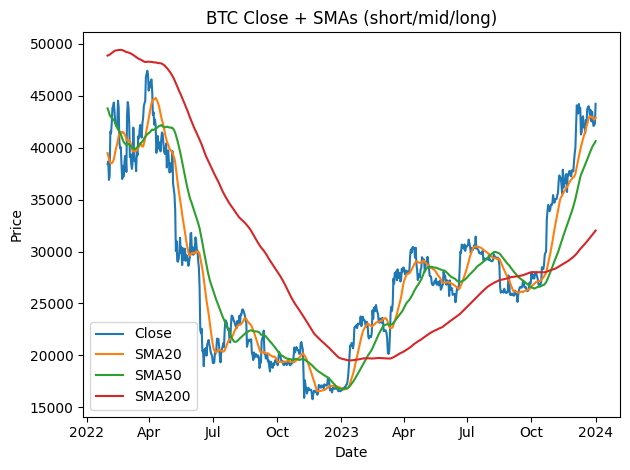

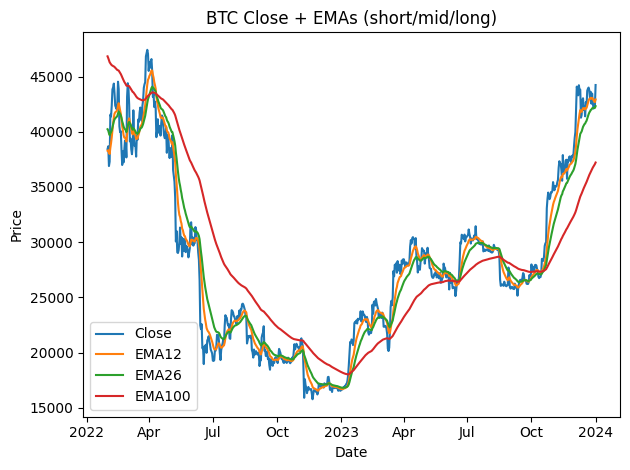

In [ ]:

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Dùng khoảng gần đây cho rõ (vd: 2 năm cuối); bạn có thể bỏ filter này để xem full
recent = df[df["timestamp"] >= (df["timestamp"].max() - pd.Timedelta(days=700))].copy()

# Biểu đồ 1: Close + SMAs
plt.figure()
plt.plot(recent["timestamp"], recent["close"], label="Close")
plt.plot(recent["timestamp"], recent[f"sma{SMA_SHORT}"], label=f"SMA{SMA_SHORT}")
plt.plot(recent["timestamp"], recent[f"sma{SMA_MID}"],   label=f"SMA{SMA_MID}")
plt.plot(recent["timestamp"], recent[f"sma{SMA_LONG}"],  label=f"SMA{SMA_LONG}")
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.gca().xaxis.set_major_formatter(mdates.ConciseDateFormatter(mdates.AutoDateLocator()))
plt.title("BTC Close + SMAs (short/mid/long)")
plt.legend()
plt.xlabel("Date"); plt.ylabel("Price")
plt.tight_layout()
plt.show()

# Biểu đồ 2: Close + EMAs
plt.figure()
plt.plot(recent["timestamp"], recent["close"], label="Close")
plt.plot(recent["timestamp"], recent[f"ema{EMA_SHORT}"], label=f"EMA{EMA_SHORT}")
plt.plot(recent["timestamp"], recent[f"ema{EMA_MID}"],   label=f"EMA{EMA_MID}")
plt.plot(recent["timestamp"], recent[f"ema{EMA_LONG}"],  label=f"EMA{EMA_LONG}")
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.gca().xaxis.set_major_formatter(mdates.ConciseDateFormatter(mdates.AutoDateLocator()))
plt.title("BTC Close + EMAs (short/mid/long)")
plt.legend()
plt.xlabel("Date"); plt.ylabel("Price")
plt.tight_layout()
plt.show()


### Cell 6 — Momentum Indicators (RSI, Stochastic, ROC, Williams %R, MACD)

- **Mục tiêu:** Tính và trực quan các **chỉ báo dao động** để đo sức mạnh/xung lực giá trong ~365 ngày gần nhất.

- **RSI(14)** — Wilder (strict):
  - Đo tốc độ tăng/giảm gần đây: `RSI = 100 - 100/(1+RS)` với `RS = AvgGain/AvgLoss`.
  - Ngưỡng tham khảo: >70 quá mua, <30 quá bán.
  - **NaN 14 dòng đầu** do warm-up theo Wilder ⇒ đúng kỳ vọng.

- **Stochastic Oscillator (%K, %D)**:
  - %K đo vị trí giá đóng cửa trong biên [low, high] của `n` phiên; %D là SMA của %K.
  - >80 quá mua, <20 quá bán; phân kỳ %K vs giá gợi ý suy yếu động lượng.

- **ROC(n)** — Rate of Change:
  - % thay đổi so với `n` phiên trước: `ROC = (Close/Close_n-1 - 1)*100`.
  - >0 động lượng tăng, <0 động lượng giảm.

- **Williams %R(n)**:
  - Dao động [-100, 0], tương tự Stoch nhưng đảo dấu: >−20 quá mua, <−80 quá bán.

- **MACD (12,26,9)**:
  - `MACD = EMA12 − EMA26`, **Signal** = EMA9(MACD), **Hist** = MACD − Signal.
  - Cắt lên Signal → bias tăng; histogram >0 củng cố xu hướng.

- **Trực quan:** Mỗi chỉ báo vẽ **một plot riêng**, trục thời gian auto-format; giúp đọc vùng quá mua/quá bán, crossovers, phân kỳ.

- **Lưu ý:** Các chỉ báo dao động **nhạy** nhưng dễ nhiễu trong trend mạnh → nên kết hợp với **MA/EMA** và khối lượng để lọc tín hiệu.


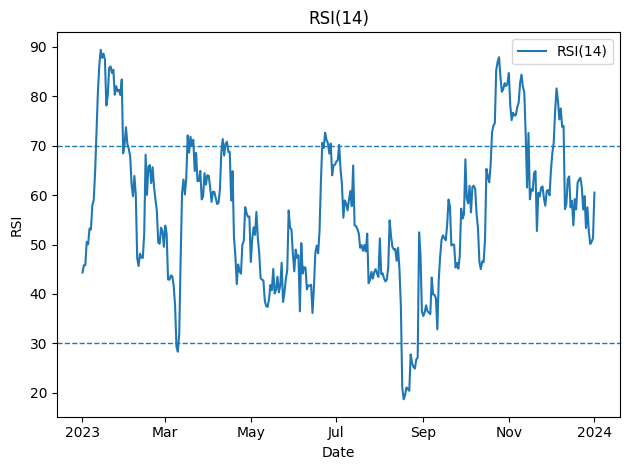

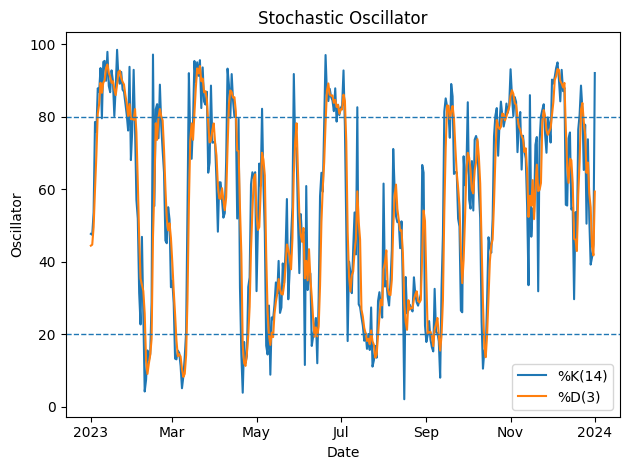

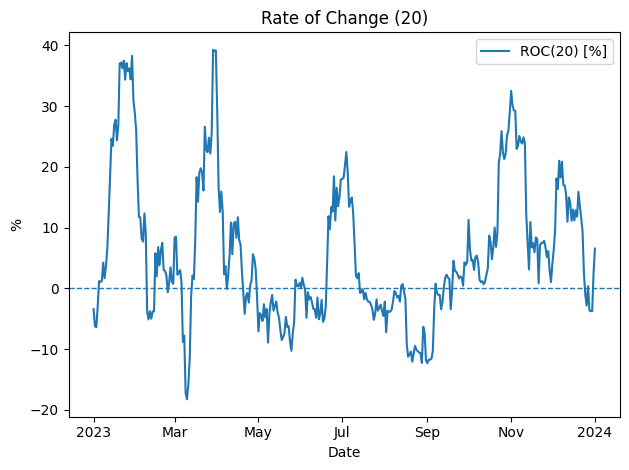

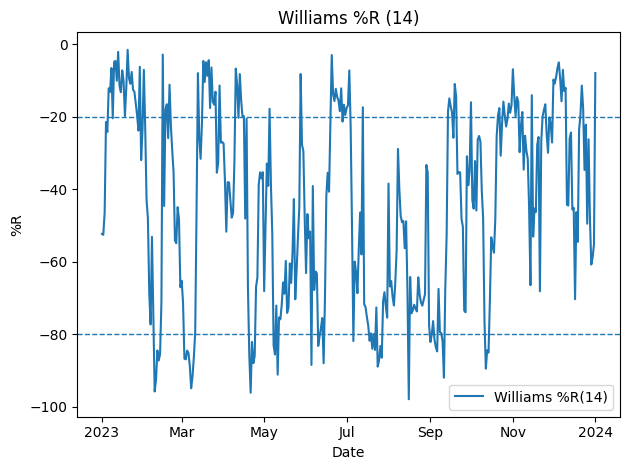

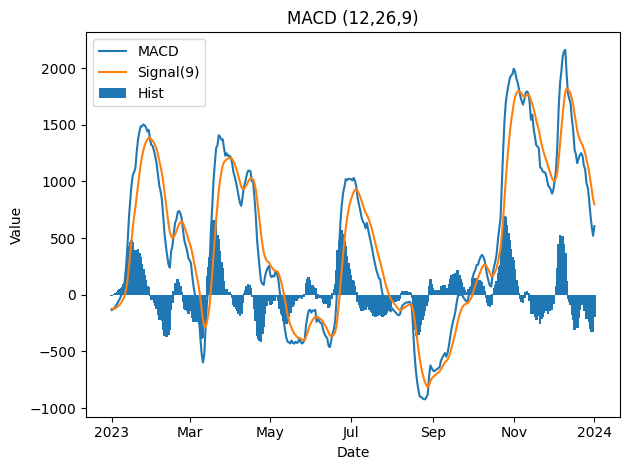

[NA counts — Oscillators]
 rsi14          14
stoch_k        13
stoch_d        15
roc20          20
wpr14          13
macd            0
macd_signal     0
macd_hist       0
dtype: int64


In [ ]:
# CELL — Momentum Indicators (RSI, Stoch, ROC, Williams %R, MACD) + plots
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ==== 0) Chuẩn bị ====
assert set(["timestamp","open","high","low","close","volume"]).issubset(df.columns), "Thiếu cột OHLCV"
df = df.sort_values("timestamp").copy()

# subset gần đây cho dễ nhìn (vd: 365 ngày cuối)
recent_days = 365
recent = df[df["timestamp"] >= (df["timestamp"].max() - pd.Timedelta(days=recent_days))].copy()

# ==== 1) RSI(14) — Wilder 'strict' (14 NaN đầu) ====
period = 14
delta = df["close"].diff()
gain  = delta.clip(lower=0.0)
loss  = (-delta).clip(lower=0.0)

avg_gain = gain.rolling(period, min_periods=period).mean()
avg_loss = loss.rolling(period, min_periods=period).mean()

avg_gain = avg_gain.copy()
avg_loss = avg_loss.copy()
for i in range(period + 1, len(df)):
    avg_gain.iat[i] = (avg_gain.iat[i-1] * (period - 1) + gain.iat[i]) / period
    avg_loss.iat[i] = (avg_loss.iat[i-1] * (period - 1) + loss.iat[i]) / period

rs = avg_gain / avg_loss.replace(0, np.nan)
df["rsi14"] = 100 - (100 / (1 + rs))

# Plot RSI
r = df[df["timestamp"] >= (df["timestamp"].max() - pd.Timedelta(days=recent_days))]
plt.figure()
plt.plot(r["timestamp"], r["rsi14"], label="RSI(14)")
plt.axhline(70, linestyle="--", linewidth=1)
plt.axhline(30, linestyle="--", linewidth=1)
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.gca().xaxis.set_major_formatter(mdates.ConciseDateFormatter(mdates.AutoDateLocator()))
plt.title("RSI(14)")
plt.xlabel("Date"); plt.ylabel("RSI")
plt.legend()
plt.tight_layout()
plt.show()

# ==== 2) Stochastic Oscillator (%K, %D) ====
STO_K, STO_D = 14, 3
low_n  = df["low"].rolling(STO_K).min()
high_n = df["high"].rolling(STO_K).max()
df["stoch_k"] = 100 * (df["close"] - low_n) / (high_n - low_n)
df["stoch_d"] = df["stoch_k"].rolling(STO_D).mean()

r = df[df["timestamp"] >= (df["timestamp"].max() - pd.Timedelta(days=recent_days))]
plt.figure()
plt.plot(r["timestamp"], r["stoch_k"], label="%K(14)")
plt.plot(r["timestamp"], r["stoch_d"], label="%D(3)")
plt.axhline(80, linestyle="--", linewidth=1)
plt.axhline(20, linestyle="--", linewidth=1)
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.gca().xaxis.set_major_formatter(mdates.ConciseDateFormatter(mdates.AutoDateLocator()))
plt.title("Stochastic Oscillator")
plt.xlabel("Date"); plt.ylabel("Oscillator")
plt.legend()
plt.tight_layout()
plt.show()

# ==== 3) ROC — Rate of Change (n ngày) ====
ROC_N = 20
df[f"roc{ROC_N}"] = df["close"].pct_change(ROC_N) * 100.0  # %
r = df[df["timestamp"] >= (df["timestamp"].max() - pd.Timedelta(days=recent_days))]
plt.figure()
plt.plot(r["timestamp"], r[f"roc{ROC_N}"], label=f"ROC({ROC_N}) [%]")
plt.axhline(0, linestyle="--", linewidth=1)
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.gca().xaxis.set_major_formatter(mdates.ConciseDateFormatter(mdates.AutoDateLocator()))
plt.title(f"Rate of Change ({ROC_N})")
plt.xlabel("Date"); plt.ylabel("%")
plt.legend()
plt.tight_layout()
plt.show()

# ==== 4) Williams %R (n=14) ====
WPR_N = 14
hh = df["high"].rolling(WPR_N).max()
ll = df["low"].rolling(WPR_N).min()
df[f"wpr{WPR_N}"] = -100 * (hh - df["close"]) / (hh - ll)

r = df[df["timestamp"] >= (df["timestamp"].max() - pd.Timedelta(days=recent_days))]
plt.figure()
plt.plot(r["timestamp"], r[f"wpr{WPR_N}"], label=f"Williams %R({WPR_N})")
plt.axhline(-20, linestyle="--", linewidth=1)
plt.axhline(-80, linestyle="--", linewidth=1)
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.gca().xaxis.set_major_formatter(mdates.ConciseDateFormatter(mdates.AutoDateLocator()))
plt.title(f"Williams %R ({WPR_N})")
plt.xlabel("Date"); plt.ylabel("%R")
plt.legend()
plt.tight_layout()
plt.show()

# ==== 5) MACD (12,26,9) ====
ema12 = df["close"].ewm(span=12, adjust=False).mean()
ema26 = df["close"].ewm(span=26, adjust=False).mean()
df["macd"] = ema12 - ema26
df["macd_signal"] = df["macd"].ewm(span=9, adjust=False).mean()
df["macd_hist"] = df["macd"] - df["macd_signal"]

r = df[df["timestamp"] >= (df["timestamp"].max() - pd.Timedelta(days=recent_days))]
plt.figure()
plt.plot(r["timestamp"], r["macd"], label="MACD")
plt.plot(r["timestamp"], r["macd_signal"], label="Signal(9)")
# histogram (cùng 1 plot)
plt.bar(r["timestamp"], r["macd_hist"], width=2.0, label="Hist")
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.gca().xaxis.set_major_formatter(mdates.ConciseDateFormatter(mdates.AutoDateLocator()))
plt.title("MACD (12,26,9)")
plt.xlabel("Date"); plt.ylabel("Value")
plt.legend()
plt.tight_layout()
plt.show()

# ==== 6) Kiểm tra NaN (kỳ vọng có NaN warm-up ở đầu, là bình thường) ====
na_counts = df[["rsi14","stoch_k","stoch_d",f"roc{ROC_N}",f"wpr{WPR_N}","macd","macd_signal","macd_hist"]].isna().sum()
print("[NA counts — Oscillators]\n", na_counts)


### Cell 7 — Volume Indicators (Vol MA/Ratio, OBV, MFI)

- **Mục tiêu:** Đánh giá sức mạnh xu hướng qua **khối lượng** trong ~1 năm gần nhất.

- **Volume MA & Volume Ratio**
  - `vol_ma20`, `vol_ma60`: trung bình trượt khối lượng ngắn/dài hạn.
  - `vol_ratio` = `volume` / `vol_ma` → >1: khối lượng hiện tại cao hơn trung bình (xác nhận/bứt phá); <1: suy yếu.
  - Biểu đồ 1–2: xem các **cụm đột biến** volume và xu hướng nền của MA.

- **OBV (On-Balance Volume)**
  - Cộng dồn khối lượng theo hướng giá: tăng ngày tăng, trừ ngày giảm.
  - Đường OBV **dốc lên** xác nhận dòng tiền vào (ủng hộ xu hướng tăng), dốc xuống thì ngược lại.

- **MFI(14) — Money Flow Index**
  - Dùng **typical price × volume**, tách dòng tiền dương/âm rồi tính chỉ số 0–100.
  - >80: quá mua, <20: quá bán; vùng cực trị + phân kỳ có giá trị cảnh báo.

- **Lưu ý:** Các chỉ báo khối lượng giúp **xác nhận** tín hiệu từ MA/EMA hoặc momentum; vẫn cần backtest để định ngưỡng và quy tắc vào/ra lệnh.


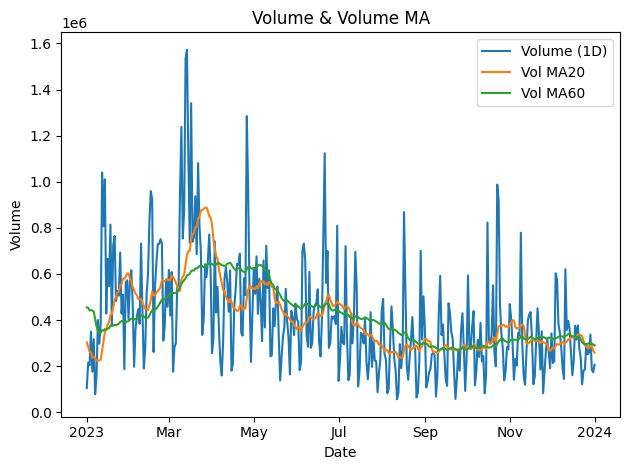

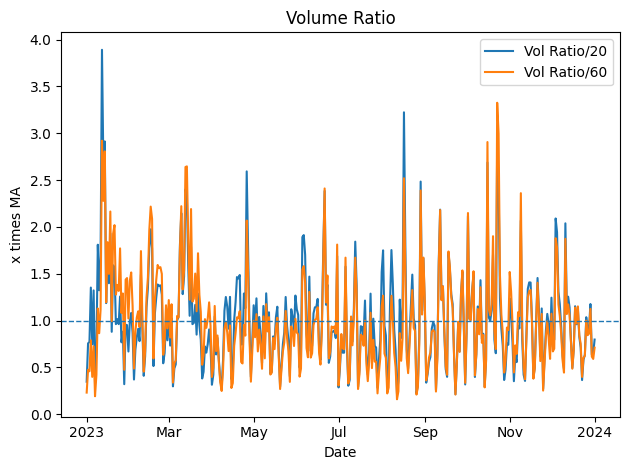

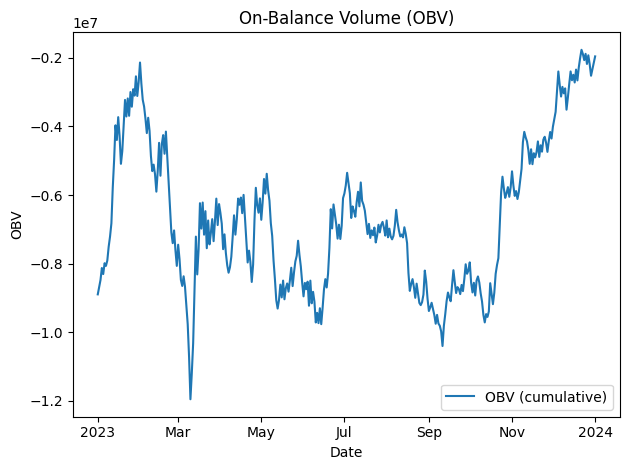

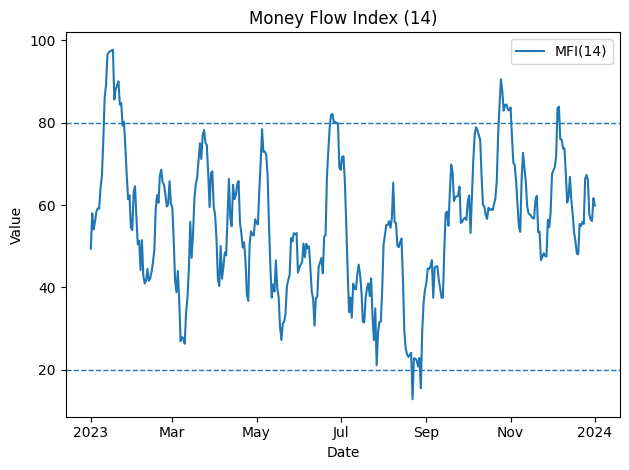

[NA counts — 3 volume indicators]
vol_ma20       19
vol_ma60       59
vol_ratio_s    19
vol_ratio_l    59
obv             0
mfi14          13
dtype: int64


In [ ]:
# CELL — Volume: Vol MA & Ratio, OBV, MFI (3 indicators) + plots
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

assert set(["timestamp","open","high","low","close","volume"]).issubset(df.columns), "Thiếu cột OHLCV"
df = df.sort_values("timestamp").copy()

# === Tham số ===
VOL_S, VOL_L = 20, 60     # MA ngắn/dài cho khối lượng
MFI_N        = 14         # Money Flow Index
recent_days  = 365        # cửa sổ trực quan gần đây

# === (1) Volume MA & Volume Ratio ===
df[f"vol_ma{VOL_S}"] = df["volume"].rolling(VOL_S).mean()
df[f"vol_ma{VOL_L}"] = df["volume"].rolling(VOL_L).mean()
df["vol_ratio_s"]    = df["volume"] / df[f"vol_ma{VOL_S}"]
df["vol_ratio_l"]    = df["volume"] / df[f"vol_ma{VOL_L}"]

# === (2) OBV (On-Balance Volume) ===
chg = np.sign(df["close"].diff().fillna(0.0))   # tăng: +1, giảm: -1, bằng: 0
df["obv"] = (df["volume"] * chg).cumsum()

# === (3) MFI (Money Flow Index) ===
tp = (df["high"] + df["low"] + df["close"]) / 3.0  # typical price
raw_mf = tp * df["volume"]
tp_diff = tp.diff()
pos_mf = raw_mf.where(tp_diff > 0, 0.0)
neg_mf = raw_mf.where(tp_diff < 0, 0.0)
pos_sum = pos_mf.rolling(MFI_N, min_periods=MFI_N).sum()
neg_sum = neg_mf.rolling(MFI_N, min_periods=MFI_N).sum().replace(0, np.nan)
mfr = pos_sum / neg_sum
df[f"mfi{MFI_N}"] = 100 - (100 / (1 + mfr))

# === Trực quan (mỗi biểu đồ 1 plot riêng) ===
recent = df[df["timestamp"] >= (df["timestamp"].max() - pd.Timedelta(days=recent_days))].copy()

# (a) Volume + MA + Ratio (vẽ 2 trục cho dễ đọc)
plt.figure()
plt.plot(recent["timestamp"], recent["volume"], label="Volume (1D)")
plt.plot(recent["timestamp"], recent[f"vol_ma{VOL_S}"], label=f"Vol MA{VOL_S}")
plt.plot(recent["timestamp"], recent[f"vol_ma{VOL_L}"], label=f"Vol MA{VOL_L}")
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.gca().xaxis.set_major_formatter(mdates.ConciseDateFormatter(mdates.AutoDateLocator()))
plt.title("Volume & Volume MA")
plt.xlabel("Date"); plt.ylabel("Volume")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure()
plt.plot(recent["timestamp"], recent["vol_ratio_s"], label=f"Vol Ratio/{VOL_S}")
plt.plot(recent["timestamp"], recent["vol_ratio_l"], label=f"Vol Ratio/{VOL_L}")
plt.axhline(1.0, linestyle="--", linewidth=1)
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.gca().xaxis.set_major_formatter(mdates.ConciseDateFormatter(mdates.AutoDateLocator()))
plt.title("Volume Ratio")
plt.xlabel("Date"); plt.ylabel("x times MA")
plt.legend()
plt.tight_layout()
plt.show()

# (b) OBV
plt.figure()
plt.plot(recent["timestamp"], recent["obv"], label="OBV (cumulative)")
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.gca().xaxis.set_major_formatter(mdates.ConciseDateFormatter(mdates.AutoDateLocator()))
plt.title("On-Balance Volume (OBV)")
plt.xlabel("Date"); plt.ylabel("OBV")
plt.legend()
plt.tight_layout()
plt.show()

# (c) MFI(14)
plt.figure()
plt.plot(recent["timestamp"], recent[f"mfi{MFI_N}"], label=f"MFI({MFI_N})")
plt.axhline(80, linestyle="--", linewidth=1)
plt.axhline(20, linestyle="--", linewidth=1)
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.gca().xaxis.set_major_formatter(mdates.ConciseDateFormatter(mdates.AutoDateLocator()))
plt.title(f"Money Flow Index ({MFI_N})")
plt.xlabel("Date"); plt.ylabel("Value")
plt.legend()
plt.tight_layout()
plt.show()

# === Kiểm tra NaN (bình thường có warm-up do rolling) ===
print("[NA counts — 3 volume indicators]")
print(df[[f"vol_ma{VOL_S}", f"vol_ma{VOL_L}", "vol_ratio_s", "vol_ratio_l", "obv", f"mfi{MFI_N}"]].isna().sum())
